# **EDA - Dampak Cuaca & Idul Adha terhadap Harga Pangan Jabar**

### **1. Pendahuluan**
- Tujuan Eksplorasi: Mengidentifikasi pola pergerakan harga, volatilitas komoditas, dan korelasi antara curah hujan dengan harga pangan menjelang Idul Adha.
- Konteks Dataset: Menggunakan dataset gabungan PIHPS (Harga Pangan) dan BMKG (Cuaca) yang sudah dibersihkan.

---

### **2. Import Library & Konfigurasi**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

---
### **3. Data Loading & Inspeksi Awal**

In [41]:
df = pd.read_csv('../datasets/clean_dataset/clean_merged_dataset.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [42]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8967 entries, 0 to 8966
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tanggal            8967 non-null   datetime64[us]
 1   Harga              8967 non-null   float64       
 2   Komoditas          8967 non-null   str           
 3   Tahun_Sumber       8967 non-null   str           
 4   Idul_Adha_Date     8967 non-null   str           
 5   Days_to_Idul_Adha  8967 non-null   int64         
 6   Is_Pre_Idul_Adha   8967 non-null   int64         
 7   Is_Idul_Adha_Week  8967 non-null   int64         
 8   Day_of_Week        8967 non-null   int64         
 9   Is_Weekend         8967 non-null   int64         
 10  T2M_MIN            8967 non-null   float64       
 11  T2M_MAX            8967 non-null   float64       
 12  T2M                8967 non-null   float64       
 13  RH2M               8967 non-null   float64       
 14  PRECTOTCORR        

,Tanggal,Harga,Days_to_Idul_Adha,Is_Pre_Idul_Adha,Is_Idul_Adha_Week,Day_of_Week,Is_Weekend,T2M_MIN,T2M_MAX,T2M,...,Bulan,Minggu_ke,Hari_dalam_minggu,Bulan_sin,Bulan_cos,Harga_lag_1,Harga_lag_3,Harga_lag_7,MA_3,MA_7
count,8967,8967.000000,8967.000000,8967.000000,8967.000000,8967.000000,8967.000000,8967.000000,8967.000000,8967.000000,...,8967.000000,8967.000000,8967.000000,8.967000e+03,8.967000e+03,8946.000000,8904.000000,8820.000000,8967.000000,8967.000000
mean,2021-11-05 10:23:53.255269,35450.903312,-8.697892,0.693208,0.152225,2.957845,0.271663,17.893091,25.808197,21.292155,...,6.742389,27.456674,2.957845,-3.173407e-01,-7.702830e-01,35426.570534,35388.409704,35311.995465,35412.125014,35340.228258
min,2017-08-02 00:00:00,8500.000000,-31.000000,0.000000,0.000000,0.000000,0.000000,13.000000,22.060000,17.900000,...,4.000000,18.000000,0.000000,-1.000000e+00,-1.000000e+00,8500.000000,8500.000000,8500.000000,8500.000000,8614.285714
25%,2019-07-28 00:00:00,13250.000000,-20.000000,0.000000,0.000000,1.000000,0.000000,16.470000,25.190000,20.540000,...,6.000000,24.000000,1.000000,-8.660254e-01,-1.000000e+00,13250.000000,13200.000000,13200.000000,13250.000000,13200.000000
50%,2021-07-26 00:00:00,20700.000000,-9.000000,1.000000,0.000000,3.000000,0.000000,18.150000,25.890000,21.360000,...,7.000000,27.000000,3.000000,-5.000000e-01,-8.660254e-01,20675.000000,20600.000000,20575.000000,20650.000000,20621.428571
75%,2024-05-30 00:00:00,38600.000000,2.000000,1.000000,0.000000,5.000000,1.000000,19.210000,26.510000,22.050000,...,8.000000,31.000000,5.000000,1.224647e-16,-5.000000e-01,38600.000000,38600.000000,38550.000000,38766.666667,38867.857143
max,2026-05-25 00:00:00,159700.000000,14.000000,1.000000,1.000000,6.000000,1.000000,22.590000,28.370000,24.280000,...,9.000000,37.000000,6.000000,8.660254e-01,-1.836970e-16,155950.000000,155950.000000,155700.000000,157200.000000,156414.285714
std,NaN,36005.662588,12.691779,0.461188,0.359259,1.984382,0.444842,1.838280,1.095215,1.172795,...,1.140817,4.745273,1.984382,4.923548e-01,2.521504e-01,35987.155780,35963.616358,35916.469385,35953.988994,35865.445001


**Insights :** 
Data merupakan tipe data *time-series* yang berisi harga-harga bahan makanan dari tahun ke tahun.

---

### **4. Analisis Univariat: Memahami Distribusi**

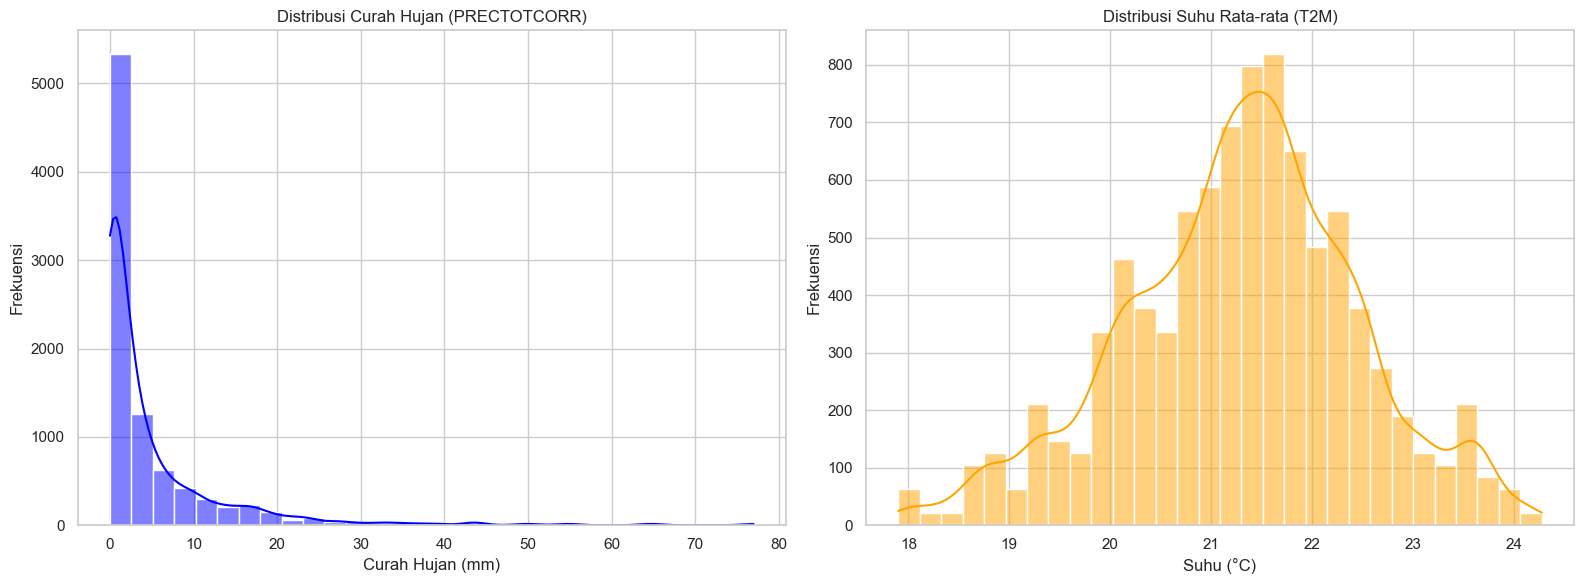

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Curah Hujan
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Curah Hujan (PRECTOTCORR)')
axes[0].set_xlabel('Curah Hujan (mm)')
axes[0].set_ylabel('Frekuensi')

# Histogram Suhu
sns.histplot(df['T2M'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribusi Suhu Rata-rata (T2M)')
axes[1].set_xlabel('Suhu (°C)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

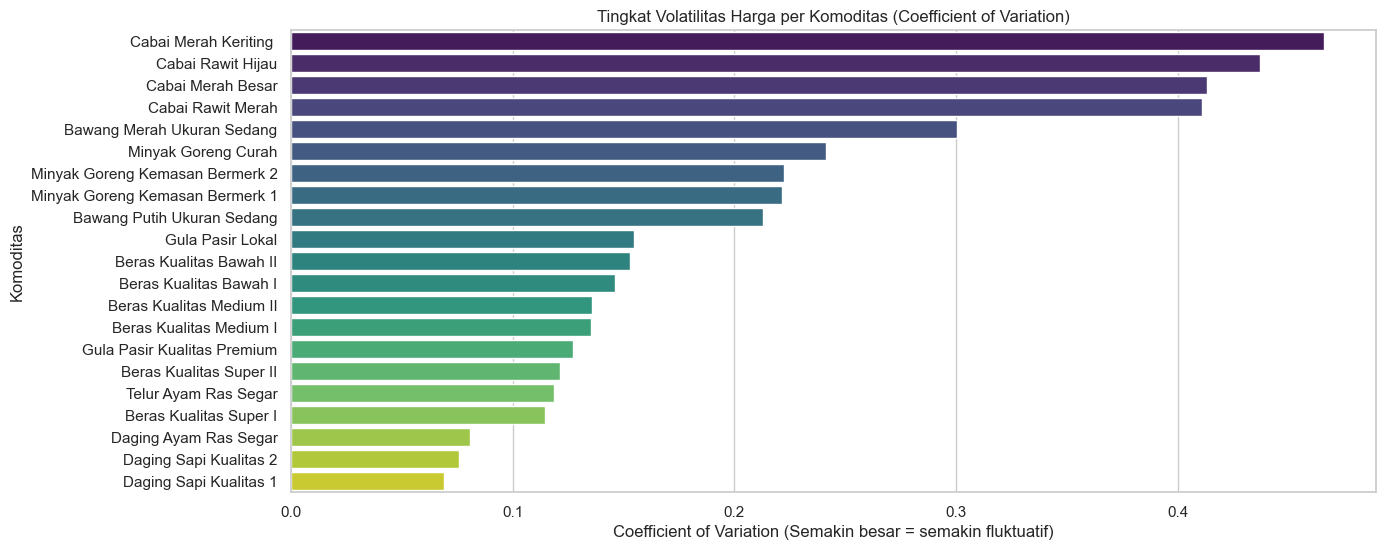

In [44]:
# Menghitung Coefficient of Variation (CV) = std / mean
cv_df = df.groupby('Komoditas')['Harga'].agg(['std', 'mean']).reset_index()
cv_df['CV'] = cv_df['std'] / cv_df['mean']
cv_df = cv_df.sort_values(by='CV', ascending=False)

# Visualisasi
plt.figure(figsize=(14, 6))
sns.barplot(data=cv_df, x='CV', y='Komoditas', palette='viridis')
plt.title('Tingkat Volatilitas Harga per Komoditas (Coefficient of Variation)')
plt.xlabel('Coefficient of Variation (Semakin besar = semakin fluktuatif)')
plt.ylabel('Komoditas')
plt.show()

---

### **5. Analisis Bivariat & Time-Series: Pola Jelang Idul Adha**

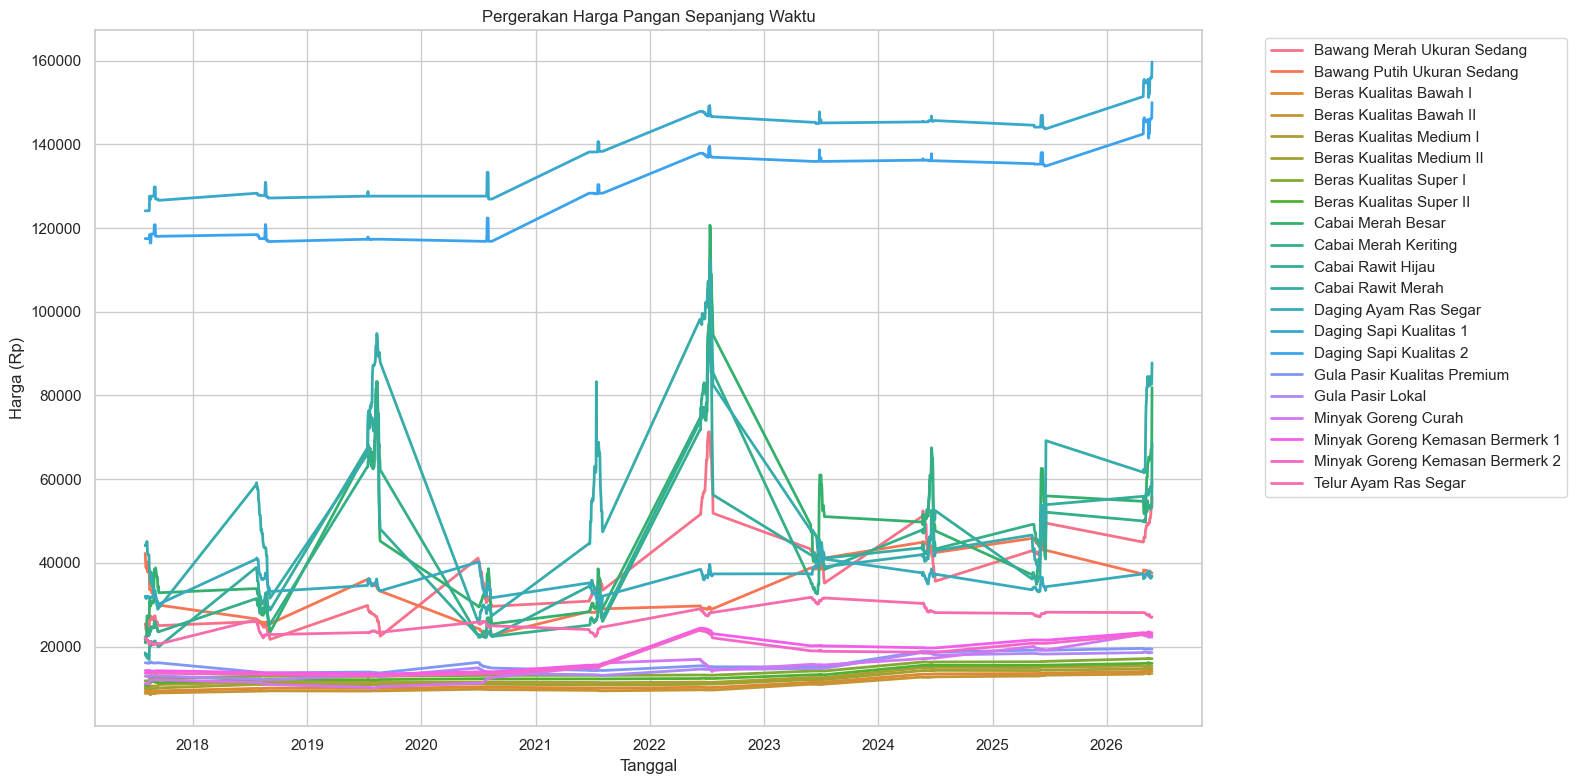

In [45]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x='Tanggal', y='Harga', hue='Komoditas', linewidth=2)
plt.title('Pergerakan Harga Pangan Sepanjang Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Memindahkan legenda ke luar grafik
plt.tight_layout()
plt.show()

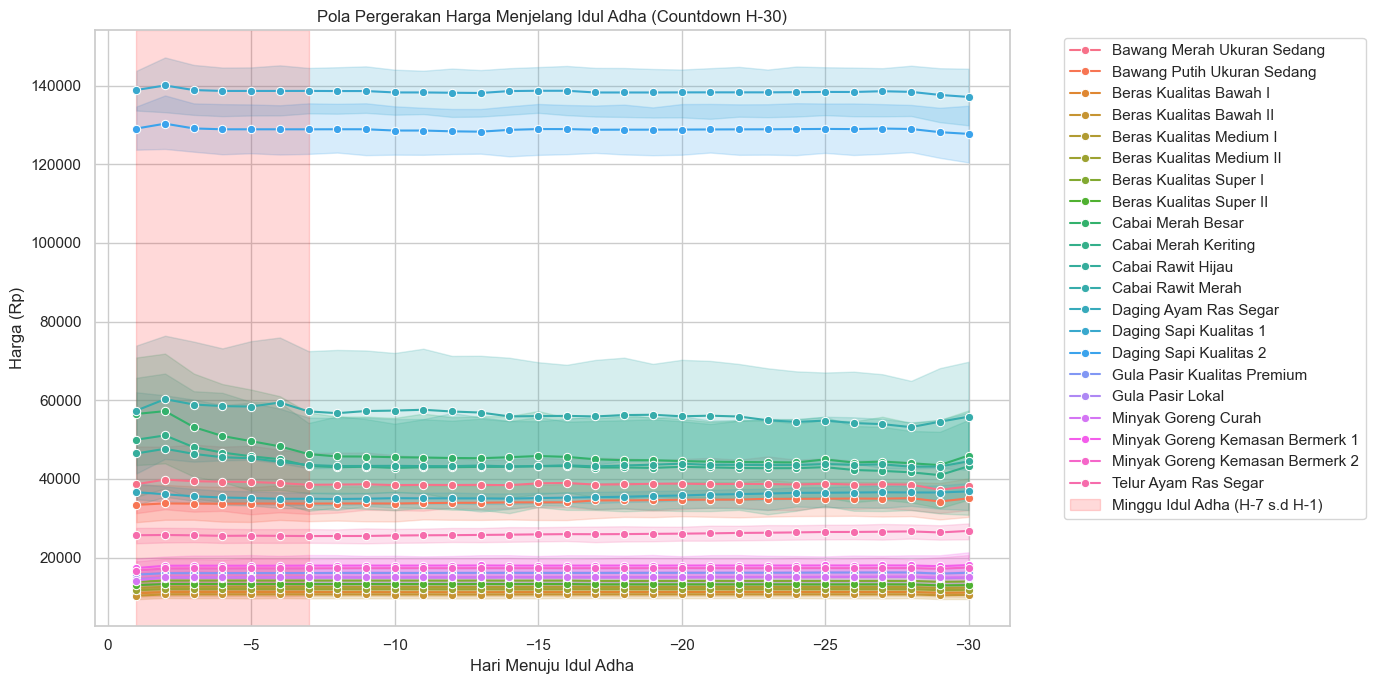

In [46]:
plt.figure(figsize=(14, 7))

# Filter data hanya untuk H-30 hingga H-1 (Pre-Idul Adha)
df_countdown = df[(df['Is_Pre_Idul_Adha'] == 1) & (df['Days_to_Idul_Adha'] < 0)]

sns.lineplot(data=df_countdown, x='Days_to_Idul_Adha', y='Harga', hue='Komoditas', marker='o')

# Menambahkan tanda highlight untuk Minggu Idul Adha (H-7 s.d. H-1)
plt.axvspan(-7, -1, color='red', alpha=0.15, label='Minggu Idul Adha (H-7 s.d H-1)')

plt.title('Pola Pergerakan Harga Menjelang Idul Adha (Countdown H-30)')
plt.xlabel('Hari Menuju Idul Adha')
plt.ylabel('Harga (Rp)')
plt.gca().invert_xaxis() # Membalik sumbu X agar seolah "menghitung mundur" ke 0
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

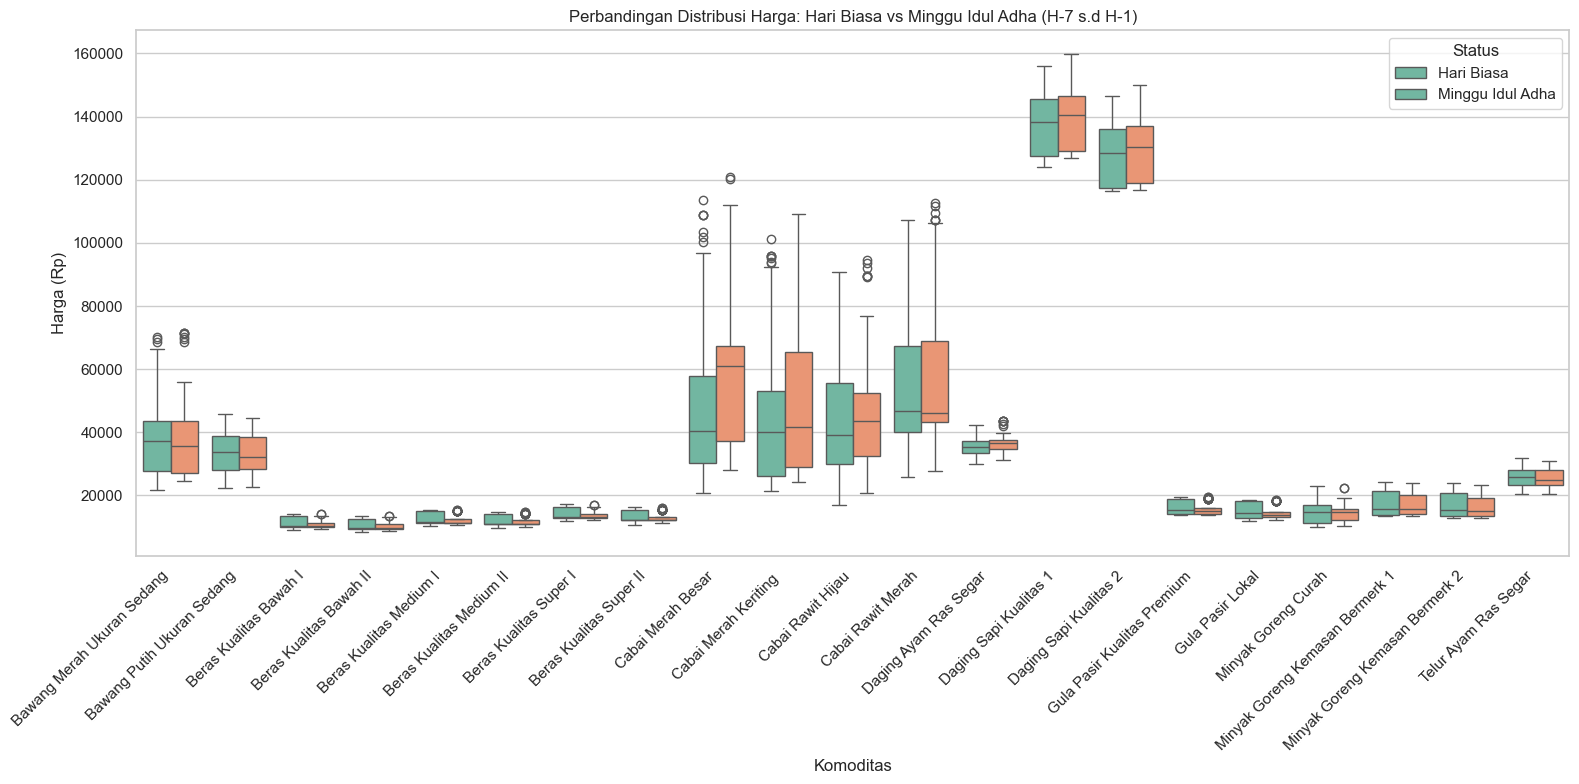

In [47]:
# Memisahkan status momen: 1 = Minggu Idul Adha, 0 = Hari Biasa di masa observasi
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='Komoditas', y='Harga', hue='Is_Idul_Adha_Week', palette='Set2')

plt.title('Perbandingan Distribusi Harga: Hari Biasa vs Minggu Idul Adha (H-7 s.d H-1)')
plt.xlabel('Komoditas')
plt.ylabel('Harga (Rp)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', labels=['Hari Biasa', 'Minggu Idul Adha'])
plt.tight_layout()
plt.show()

---

### **6. Analisis Diagnostik: Korelasi Cuaca dan Harga**

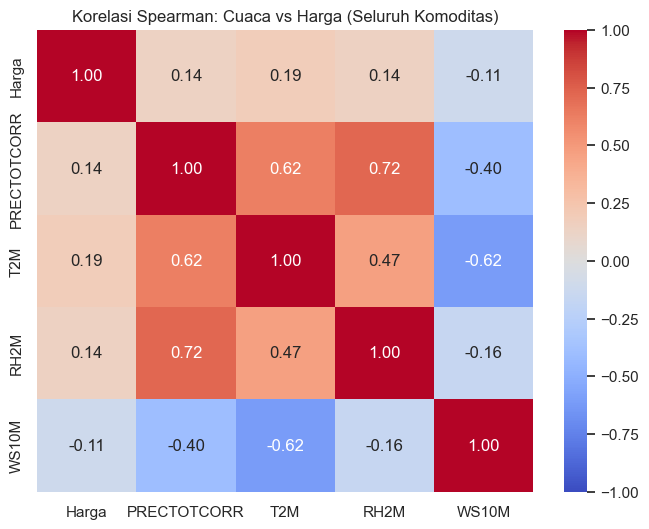

In [48]:
# Memilih kolom cuaca dan harga
cols_to_correlate = ['Harga', 'PRECTOTCORR', 'T2M', 'RH2M', 'WS10M']
corr_matrix = df[cols_to_correlate].corr(method='spearman') # Memakai Spearman karena distribusi mungkin tidak normal

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelasi Spearman: Cuaca vs Harga (Seluruh Komoditas)')
plt.show()

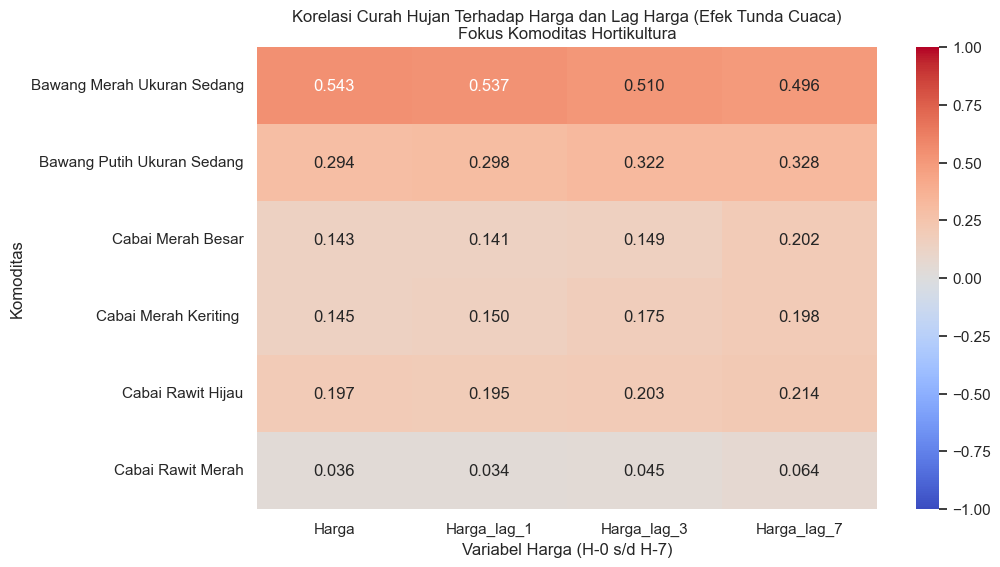

In [49]:
# Filter hanya komoditas Bawang dan Cabai
horti_komoditas = df['Komoditas'].str.contains('Bawang|Cabai', case=False, na=False)
df_horti = df[horti_komoditas]

# Kita akan melihat korelasi Curah Hujan dengan Harga pada rentang waktu yang berbeda
lag_cols = ['Harga', 'Harga_lag_1', 'Harga_lag_3', 'Harga_lag_7']

# Mengumpulkan nilai korelasi untuk divisualisasikan
korelasi_hujan = []

for komoditas in df_horti['Komoditas'].unique():
    df_temp = df_horti[df_horti['Komoditas'] == komoditas]
    
    # Hitung korelasi spearman curah hujan terhadap harga dan lagged harga
    corr_values = df_temp[['PRECTOTCORR'] + lag_cols].corr(method='spearman').loc['PRECTOTCORR', lag_cols]
    
    # Simpan dalam dataframe sementara
    temp_df = pd.DataFrame(corr_values).T
    temp_df['Komoditas'] = komoditas
    korelasi_hujan.append(temp_df)

# Gabungkan data korelasi
korelasi_hujan_df = pd.concat(korelasi_hujan).set_index('Komoditas')

# Visualisasi heatmap korelasi lag
plt.figure(figsize=(10, 6))
sns.heatmap(korelasi_hujan_df, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Korelasi Curah Hujan Terhadap Harga dan Lag Harga (Efek Tunda Cuaca)\nFokus Komoditas Hortikultura')
plt.xlabel('Variabel Harga (H-0 s/d H-7)')
plt.ylabel('Komoditas')
plt.show()

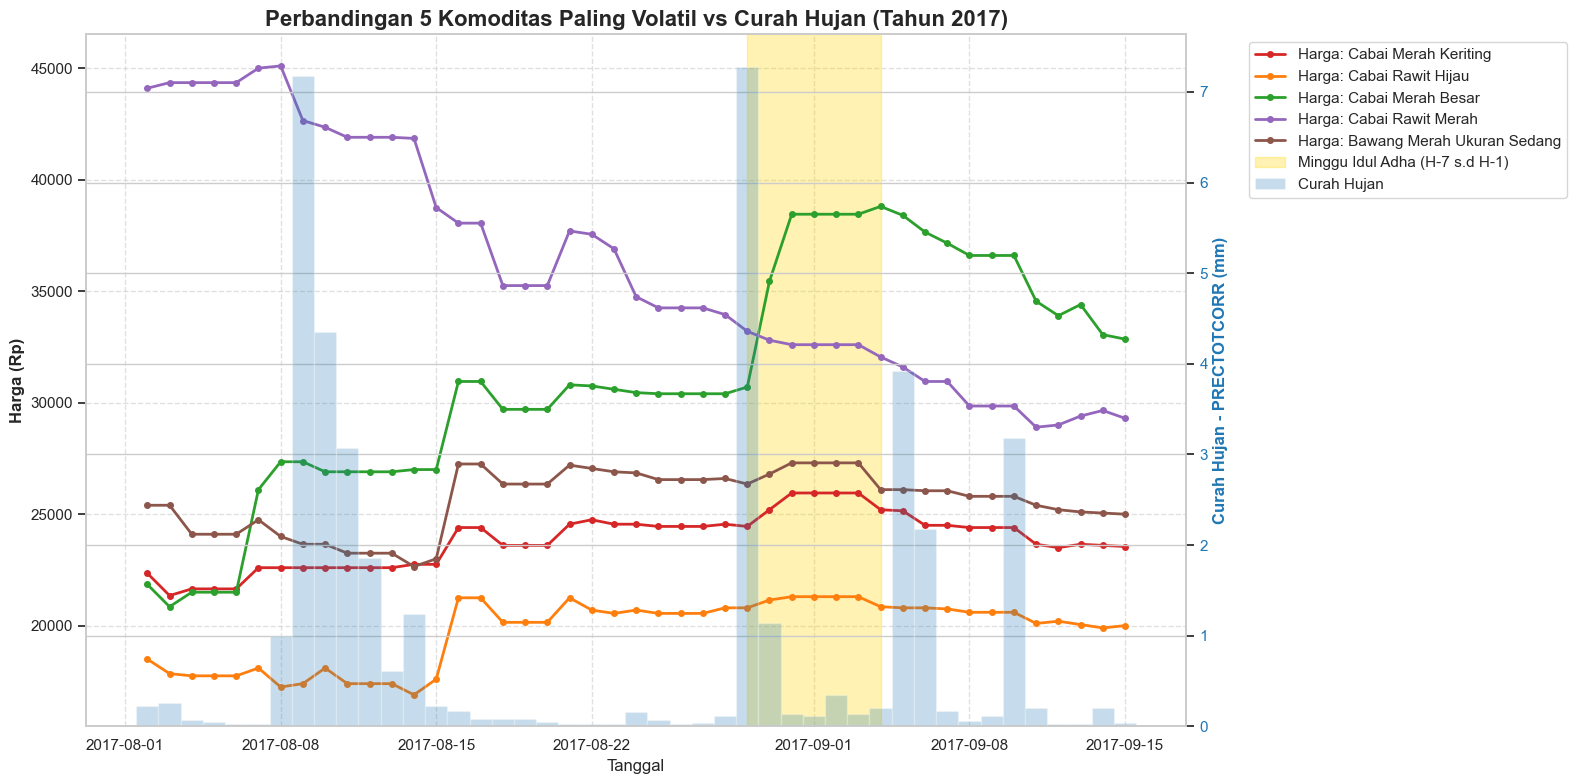

In [50]:
# 5 Komoditas dengan Volatilitas (CV) Tertinggi
cv_df = df.groupby('Komoditas')['Harga'].agg(['std', 'mean']).reset_index()
cv_df['CV'] = cv_df['std'] / cv_df['mean']
top_5_komoditas = cv_df.sort_values(by='CV', ascending=False).head(5)['Komoditas'].tolist()

# Filter 1 Tahun Sampel agar Time-Series terbaca jelas
df_sample_year = df.copy()
df_sample_year['Tahun'] = df_sample_year['Tanggal'].dt.year
tahun_sampel = df_sample_year['Tahun'].unique()[0] 
df_year = df_sample_year[df_sample_year['Tahun'] == tahun_sampel]

# Inisialisasi Grafik (Dual-Axis)
fig, ax1 = plt.subplots(figsize=(16, 8))

# Daftar warna untuk 5 komoditas agar kontras dan mudah dibedakan
colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

# --- SUMBU Y KIRI: Plot Harga (5 Garis) ---
ax1.set_xlabel('Tanggal', fontsize=12)
ax1.set_ylabel('Harga (Rp)', fontsize=12, fontweight='bold')

for idx, komoditas in enumerate(top_5_komoditas):
    # Ambil data spesifik per komoditas
    df_k = df_year[df_year['Komoditas'] == komoditas].sort_values('Tanggal')
    
    # Plot garis harga
    ax1.plot(df_k['Tanggal'], df_k['Harga'], color=colors[idx], linewidth=2, 
             marker='o', markersize=4, label=f"Harga: {komoditas.strip()}")

# --- SUMBU Y KANAN: Plot Curah Hujan (Batang/Bar) ---
ax2 = ax1.twinx()  
df_weather = df_year[df_year['Komoditas'] == top_5_komoditas[0]].sort_values('Tanggal')

ax2.set_ylabel('Curah Hujan - PRECTOTCORR (mm)', color='tab:blue', fontsize=12, fontweight='bold')
ax2.bar(df_weather['Tanggal'], df_weather['PRECTOTCORR'], color='tab:blue', alpha=0.25, width=1, label='Curah Hujan')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- Highlight (Penanda) Minggu Idul Adha ---
idul_adha_week = df_weather[df_weather['Is_Idul_Adha_Week'] == 1]['Tanggal']
if not idul_adha_week.empty:
    start_date = idul_adha_week.min()
    end_date = idul_adha_week.max()
    ax1.axvspan(start_date, end_date, color='gold', alpha=0.3, label='Minggu Idul Adha (H-7 s.d H-1)')

# --- Merapikan Legend & Layout ---
# Menggabungkan legend dari ax1 dan ax2
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Meletakkan legend di luar grafik (sebelah kanan)
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=11)

ax1.grid(True, linestyle='--', alpha=0.6)
plt.title(f'Perbandingan 5 Komoditas Paling Volatil vs Curah Hujan (Tahun {tahun_sampel})', fontsize=16, fontweight='bold')

# Menyesuaikan margin agar legend di luar grafik tidak terpotong
plt.tight_layout()
plt.show()

#### **Insights :**
1. **Temuan Volatilitas (Kerentanan Harga)**
    1. Komoditas Cabai (Cabai Merah Keriting, Cabai Rawit Hijau, Cabai Merah Besar, dan Cabai Rawit Merah) menempati posisi teratas dengan Coefficient of Variation (CV) di atas 0.41. Artinya, harga cabai adalah yang paling tidak stabil dan paling rentan mengalami lonjakan ekstrem dibandingkan bahan pangan lainnya.
    2. Bawang Merah Ukuran Sedang berada di posisi kelima paling fluktuatif dengan CV sekitar 0.30.

2. **Temuan Korelasi & Efek Tunda (Lag) Cuaca**
    (Nanti)

3. **Perubahan harga menjelang idul adha**
    (Nanti)

**Kesimpulan :** (Nanti)